In [24]:
import time
import pandas as pd
import numpy as np
import requests
import matplotlib as mp

API

Getting spot data

In [25]:
#spot data

url_spot = "https://api.binance.com/api/v3/klines"

end_time = int(time.time()*1000)

start_time = end_time - (3*365*24*60*60*1000)

params = {
    "symbol" : "BTCUSDT",
    "interval" : "1d",
    "startTime" : start_time,
    "endTime" : end_time,
    "limit" : 1000
}

response = requests.get(url_spot, params=params)

data = response.json()

print(type(data))
print(len(data))
print(data[0])

<class 'list'>
1000
[1683417600000, '28848.19000000', '29138.29000000', '28395.23000000', '28430.10000000', '30003.41028000', 1683503999999, '865838535.32638210', 855425, '14904.01102000', '430162358.62942520', '0']


In [26]:
df = pd.DataFrame(data)

df = df.iloc[:,:6]
df.columns = ["timestamp", "open", "high", "low", "close", "volume"]

df["timestamp"] = pd.to_datetime(df["timestamp"], unit="ms")

for col in ["open", "high", "low", "close"]:
    df[col] = df[col].astype(float)

df.head()

,timestamp,open,high,low,close,volume
0,2023-05-07,28848.19,29138.29,28395.23,28430.10,30003.41028000
1,2023-05-08,28430.09,28631.01,27262.00,27668.79,68244.36179000
2,2023-05-09,27668.80,27818.00,27353.00,27628.27,40113.31069000
3,2023-05-10,27628.28,28331.42,26777.00,27598.75,71155.11355000
4,2023-05-11,27598.74,27630.14,26702.05,26968.62,47635.31365000


Getting Futures Data

In [27]:
url_fut = "https://fapi.binance.com/fapi/v1/klines"

response_fut = requests.get(url_fut, params=params)

data_fut = response_fut.json()

print(type(data_fut))
print(data_fut[0])

<class 'list'>
[1683417600000, '28837.90', '29137.00', '28370.00', '28419.40', '308410.643', 1683503999999, '8896354660.35729', 3445261, '150881.809', '4353309036.01683', '0']


In [28]:
df_fut = pd.DataFrame(data_fut) #puts the list into a dataframe

df_fut = df_fut.iloc[:,:6] #selects only the first 6 columns
df_fut.columns = ["timestamp", "open", "high", "low", "close", "volume"] #naming the columns

df_fut["timestamp"] = pd.to_datetime(df_fut["timestamp"], unit="ms") #changes the time from ms to date and ms 

for col in ["open", "high", "low", "close"]:
    df_fut[col] = df_fut[col].astype(float) #changes the numbers from string into float

df_fut.head()

,timestamp,open,high,low,close,volume
0,2023-05-07,28837.9,29137.0,28370.0,28419.4,308410.643
1,2023-05-08,28419.5,28624.6,27250.0,27659.8,658188.777
2,2023-05-09,27659.8,27815.6,27316.8,27610.2,367664.686
3,2023-05-10,27610.2,28297.0,26666.6,27582.9,722502.676
4,2023-05-11,27583.0,27630.0,26688.8,26956.4,538822.363


Aligning prices and timestamp of both spot and perp

In [29]:

df = df.drop("high", axis=1) # axis 0=row, 1=column
df = df.drop("low", axis=1) #deleting columns individually

df.head()

,timestamp,open,close,volume
0,2023-05-07,28848.19,28430.10,30003.41028000
1,2023-05-08,28430.09,27668.79,68244.36179000
2,2023-05-09,27668.80,27628.27,40113.31069000
3,2023-05-10,27628.28,27598.75,71155.11355000
4,2023-05-11,27598.74,26968.62,47635.31365000


In [30]:
df = df.drop(columns=["high", "low"], axis=1)

df.head()

KeyError: "['high', 'low'] not found in axis"

In [ ]:
df_fut = df_fut.drop(columns=["open", "high", "low"], axis=1) #deleting multiple columns in one line

df_fut.head()

,timestamp,close,volume
0,2023-05-07,28419.4,308410.643
1,2023-05-08,27659.8,658188.777
2,2023-05-09,27610.2,367664.686
3,2023-05-10,27582.9,722502.676
4,2023-05-11,26956.4,538822.363


In [ ]:
#checking if the timestamps are identical
is_identical = df["timestamp"].equals(df_fut["timestamp"])

print(f"Are the timestamps identical? {is_identical}")

Are the timestamps identical? True


In [ ]:
#Renaming the columns
df.columns = ["timestamp", "spot_price", "volume"]
df_fut.columns = ["timestamp", "fut_price", "volume"]


In [ ]:
#aligning all columns from future price and spot price to one dataframe
#use of concatenate to do this

df1 = pd.concat([df[["timestamp", "spot_price"]],df_fut[["fut_price"]]], axis=1).copy()

df1.head()

,timestamp,spot_price,fut_price
0,2023-05-07,28430.10,28419.4
1,2023-05-08,27668.79,27659.8
2,2023-05-09,27628.27,27610.2
3,2023-05-10,27598.75,27582.9
4,2023-05-11,26968.62,26956.4


In [ ]:
type(df1["spot_price"])

pandas.core.series.Series

In [ ]:
df1["timestamp"].duplicated().sum()

df1["timestamp"].is_monotonic_increasing

True

The code works because there is nothing missing, but if there is a timestamp duplication or a price missing for a timestamp, it falls apart. 

This is something to work on to improve this code

Plotting the prices

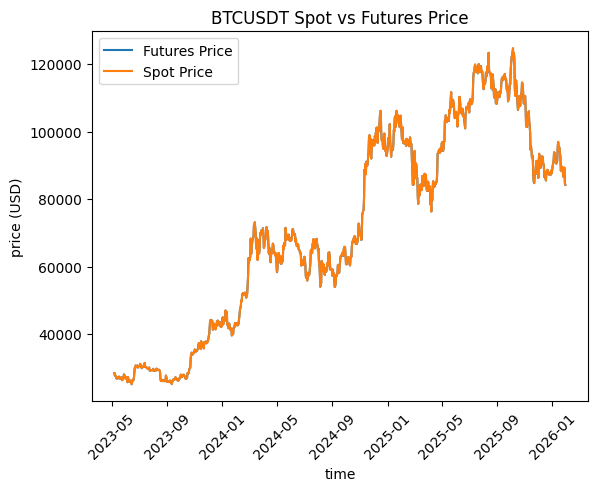

In [31]:
import matplotlib.pyplot as plt


x = df1["timestamp"]
#plt.xticks(rotation=45)

y1 = df1["fut_price"]

y2 = df1["spot_price"]


fig, ax = plt.subplots()

ax.plot(x, y1, label="Futures Price")
ax.plot(x, y2, label="Spot Price")


ax.set_xlabel("time")

ax.set_ylabel("price (USD)")

ax.set_title("BTCUSDT Spot vs Futures Price")

ax.legend()
plt.xticks(rotation=45)

plt.show()

In [32]:
spread = df1["fut_price"] - df1["spot_price"]

spread_pct = (spread)/df1["spot_price"]

rolling_mean = spread_pct.rolling(window=20).mean()

rolling_std = spread_pct.rolling(window=20).std()

z_score = (spread_pct-rolling_mean)/rolling_std

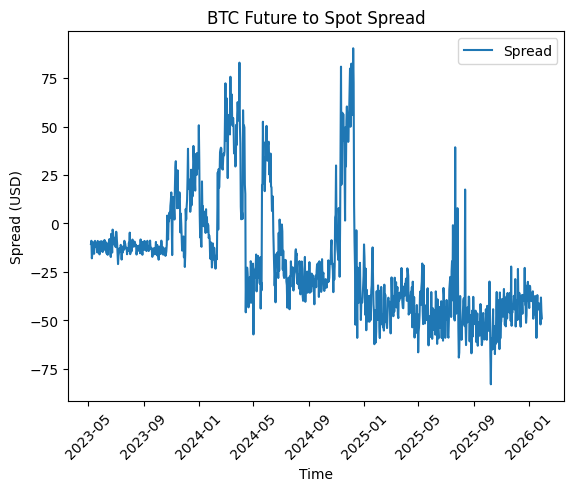

In [33]:


y3 = spread

y4 = spread_pct

fig, ax = plt.subplots()
ax.plot(x, y3, label="Spread")
#ax.plot(x, y4, label="Spread Percentage")

ax.set_xlabel("Time")
ax.set_ylabel("Spread (USD)")
ax.set_title("BTC Future to Spot Spread")

ax.legend()
plt.xticks(rotation=45)

plt.show()

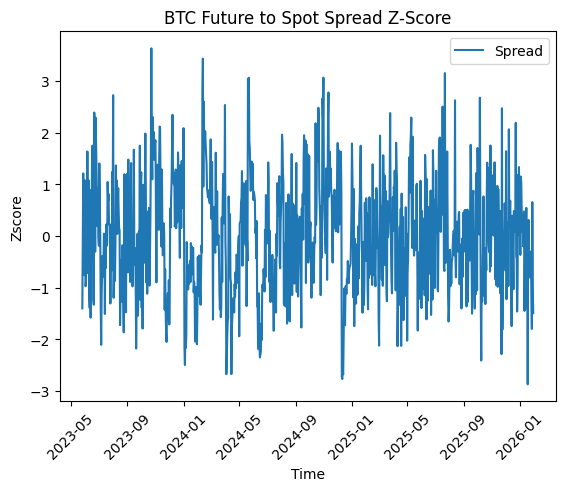

In [34]:


y5 = z_score


fig, ax = plt.subplots()
ax.plot(x, y5, label="Spread")


ax.set_xlabel("Time")
ax.set_ylabel("Zscore")
ax.set_title("BTC Future to Spot Spread Z-Score")

ax.legend()
plt.xticks(rotation=45)

plt.show()

Signal Analysis

In [73]:
#print(z_score)
df_z = pd.DataFrame(z_score)
df_z.columns = ["zscore"]


stats_df = pd.concat([df1["timestamp"], df_z["zscore"]], axis=1).copy()

short_signal = z_score > 2
long_signal = z_score < -2

long_count = (stats_df["zscore"]<-1).sum()
print(long_count)

short_count = (stats_df["zscore"] > 1).sum()
print(short_count)

total = len(stats_df)

long_freq = long_count/total
short_freq = short_count/total

print(long_freq)
print(short_freq)

182
182
0.182
0.182


In [95]:
short_signal = (stats_df["zscore"]>1) & (stats_df["zscore"].shift(1) <= 1)
short_events = short_signal.sum()

long_signal = (stats_df["zscore"]<-1) & (stats_df["zscore"].shift(1) >=-1)
long_events = long_signal.sum()

print(long_events)
print(short_events)

106
107


In [ ]:
#analysis of signals per month

#First aligning all short signals with their respective date
short_df = pd.DataFrame({"timestamp": stats_df["timestamp"],
                         "shortsig": short_signal})

#short_df.head()

#Timestamped short signals
display(short_df.loc[(short_df["shortsig"]==True)])


In [76]:
short_df = stats_df.loc[short_signal].copy()

short_df["month"] = short_df["timestamp"].dt.to_period("M")

monthly_counts = short_df.groupby("month").size()

print(monthly_counts)

month
2023-05    2
2023-06    5
2023-07    3
2023-08    5
2023-09    5
2023-10    3
2023-11    3
2023-12    6
2024-01    1
2024-02    3
2024-03    4
2024-05    5
2024-07    3
2024-08    2
2024-09    6
2024-10    3
2024-11    4
2024-12    2
2025-01    2
2025-02    1
2025-03    4
2025-04    2
2025-05    5
2025-06    3
2025-07    6
2025-08    1
2025-09    2
2025-10    6
2025-11    3
2025-12    5
2026-01    1
Freq: M, dtype: int64


Index([ 34,  37,  43,  59,  68,  80,  87, 101, 105, 108,
       ...
       932, 941, 952, 956, 964, 980, 985, 987, 995, 999],
      dtype='int64', length=107)


Understanding the nature of the mean reversion

In [77]:
#Lists each entry point as short_signal is boolean so it provides timestamp for every true entry
signal_indices = stats_df.index[short_signal]

holding_periods = []

for idx in signal_indices:
    future_data = stats_df.loc[idx+1:]

    reversion = future_data[future_data["zscore"]<=0]

    if not reversion.empty:
        t1 = reversion.index[0]
        holding_period = t1-idx
        holding_periods.append(holding_period)

print("Average days to mean revert:", np.mean(holding_periods))
print("Median:", np.median(holding_periods))
print("Max:", np.max(holding_periods))

Average days to mean revert: 4.028301886792453
Median: 2.0
Max: 23


In [78]:
df1["spread"] = df1["spot_price"] - df1["fut_price"]
df1["spread_pct"] = df1["spread"]/df1["spot_price"]
df1["rolling_mean"] = df1["spread_pct"].rolling(20).mean()
df1["rolling_std"] = df1["spread_pct"].rolling(20).std()

df1["zscore"] = (
    (df1["spread_pct"] - df1["rolling_mean"]) / df1["rolling_std"]
)

df1.head()

#Always keep features within one big dataset thet they're derived from

,timestamp,spot_price,fut_price,spread,spread_pct,rolling_mean,rolling_std,zscore
0,2023-05-07,28430.10,28419.4,10.70,0.000376,NaN,NaN,NaN
1,2023-05-08,27668.79,27659.8,8.99,0.000325,NaN,NaN,NaN
2,2023-05-09,27628.27,27610.2,18.07,0.000654,NaN,NaN,NaN
3,2023-05-10,27598.75,27582.9,15.85,0.000574,NaN,NaN,NaN
4,2023-05-11,26968.62,26956.4,12.22,0.000453,NaN,NaN,NaN


In [79]:
stats_df = df1.copy()

Adding PNL to understand the mean reversion visually and numerically

In [91]:
#pnl = entry_spread - current_spread

trades = []

for idx in signal_indices:
    entry_row = stats_df.loc[idx]
    entry_spread = entry_row["spread_pct"]

    future_data = stats_df.loc[idx+1:].copy()

    reversion = future_data[future_data["zscore"] <=0]

    trade = {}

    if not reversion.empty:
        t1 = reversion.index[0]
        trade_data = stats_df.loc[idx:t1].copy()
        reverted = True
    else:
        #trade doesn't revert, allow it to take the full path
        trade_data = stats_df.loc[idx:].copy()
        t1 = trade_data.index[-1]
        reverted = False
    
    holding_period = (
        stats_df.loc[t1, "timestamp"] - entry_row["timestamp"]
    ).days

    #pnl path
    trade_data["pnl"] = entry_spread - trade_data["spread_pct"]


    #final pnl
    final_pnl = trade_data["pnl"].iloc[-1]

    trade["entry_idx"] = idx
    trade["exit_idx"] = t1
    trade["holding_period"] = holding_period
    trade["final_pnl"] = final_pnl
    trade["reverted"] = reverted
    trade ["pnl_path"] = trade_data["pnl"].values

    trades.append(trade)






In [92]:
trades_df = pd.DataFrame(trades)

trades_df.head()

trade_data.head()

,timestamp,spot_price,fut_price,spread,spread_pct,rolling_mean,rolling_std,zscore,pnl
972,2026-01-03,90628.01,90595.8,32.21,0.000355,0.000444,0.000077,-1.152415,0.000000
973,2026-01-04,91529.73,91497.1,32.63,0.000356,0.000437,0.000078,-1.030515,-0.000001


<Axes: >

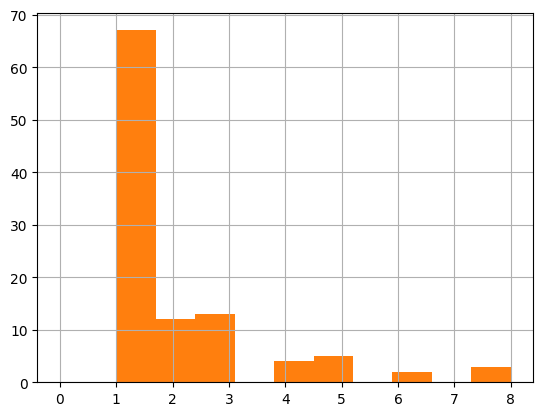

In [82]:
trades_df["final_pnl"].hist()
trades_df["holding_period"].hist()

In [83]:
trades_df.groupby("reverted")["final_pnl"].mean()

reverted
True   -0.000053
Name: final_pnl, dtype: float64

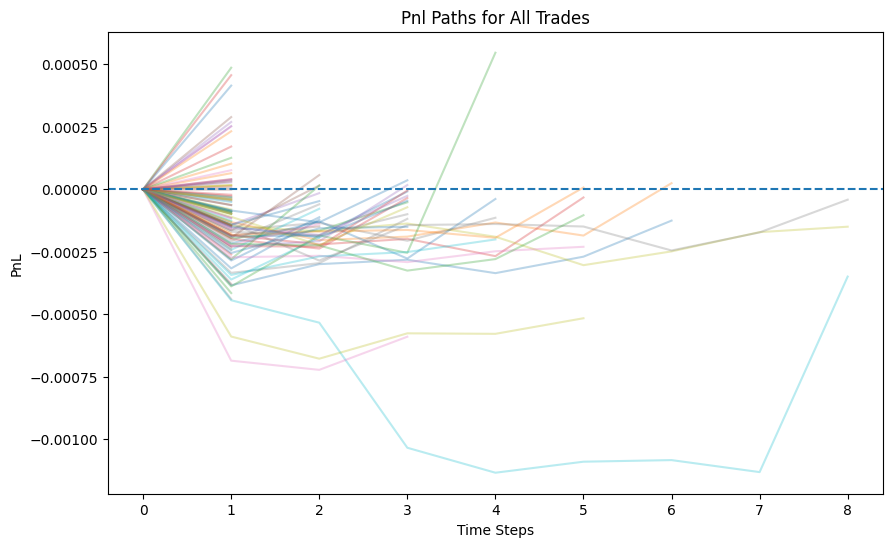

In [84]:
plt.figure(figsize=(10,6))

for trade in trades:
    plt.plot(trade["pnl_path"], alpha=0.3)

plt.axhline(0, linestyle="--") #this shows breakeven line
plt.title("Pnl Paths for All Trades")
plt.xlabel("Time Steps")
plt.ylabel("PnL")
plt.show()


In [85]:
trades_df["returns"] = trades_df["final_pnl"]

initial_capital = 1000

equity = [initial_capital]

for r in trades_df["returns"]:
    new_equity = equity[-1] * (1+r)
    equity.append(new_equity)

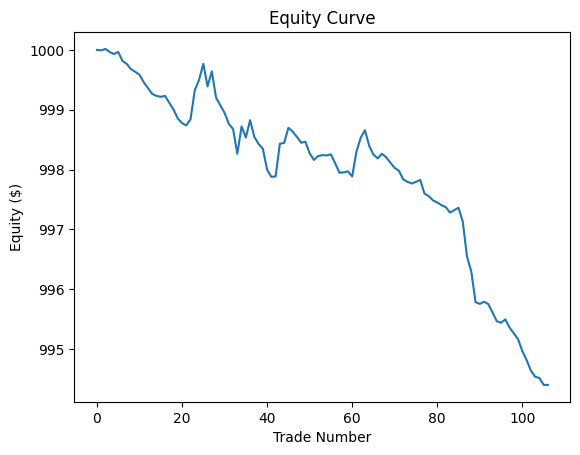

In [86]:
plt.plot(equity)
plt.title("Equity Curve")
plt.xlabel("Trade Number")
plt.ylabel("Equity ($)")
plt.show()